In [3]:
# Cell 1 — Load Data

import pandas as pd
import numpy as np
from pathlib import Path

# Load clean monthly panel
data_path = Path('data')
df = pd.read_csv(data_path / 'clean_monthly_panel.csv', parse_dates=['date'])

# Sort by date and stock
df = df.sort_values(['date', 'permno']).reset_index(drop=True)

# Check
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique stocks: {df['permno'].nunique()}")
print(f"Unique months: {df['date'].nunique()}")
print(f"\nCrisis months (market vol > 30%): {df.groupby('date')['high_vol_regime'].first().sum()}")
print(f"Exit months (lagged market vol > 30%): {(df.groupby('date')['mkt_vol_ann_lag1'].first() > 0.30).sum()}")

Shape: (1912727, 20)
Date range: 1990-01-31 00:00:00 to 2023-12-31 00:00:00
Unique stocks: 18074
Unique months: 408

Crisis months (market vol > 30%): 24
Exit months (lagged market vol > 30%): 24


In [4]:
# Cell 2 — Apply Exit Rule on top of Benchmark

def select_exit_rule_portfolio(df, n_stocks=500, vol_threshold=0.30):
    """
    Same as benchmark but exits the market entirely if lagged market vol > threshold.
    Uses mkt_vol_ann_lag1 as exit signal — observable BEFORE the month starts.
    """
    benchmark_results = []
    exit_rule_results = []

    for date, month_df in df.groupby('date'):
        
        # Get lagged market vol for this month (known before month starts)
        lagged_mkt_vol = month_df['mkt_vol_ann_lag1'].iloc[0]
        high_vol_regime = month_df['high_vol_regime'].iloc[0]
        mkt_vol = month_df['mkt_vol_ann'].iloc[0]

        # Drop stocks with missing lagged vol
        available = month_df.dropna(subset=['real_vol_ann_lag1'])

        # Need at least 500 stocks
        if len(available) < n_stocks:
            continue

        # Select 500 lowest vol stocks (same for both strategies)
        selected = available.nsmallest(n_stocks, 'real_vol_ann_lag1').copy()
        weight = 1 / n_stocks

        # Capital cost rate based on current month regime
        cost_rate = 0.30 if high_vol_regime else 0.15

        # ── Benchmark: always invested ──────────────────────
        bench_net = (selected['ret'] - cost_rate * selected['real_vol_ann_lag1'] / 12).mean()
        benchmark_results.append({
            'date'           : date,
            'avg_net_revenue': bench_net,
            'high_vol_regime': high_vol_regime,
            'mkt_vol_ann'    : mkt_vol,
            'lagged_mkt_vol' : lagged_mkt_vol,
            'invested'       : True,
        })

        # ── Exit rule: sit out if lagged market vol > 30% ──
        if pd.isna(lagged_mkt_vol) or lagged_mkt_vol > vol_threshold:
            # Exit — net revenue = 0
            exit_net = 0.0
            invested = False
        else:
            # Invest exactly like benchmark
            exit_net = bench_net
            invested = True

        exit_rule_results.append({
            'date'           : date,
            'avg_net_revenue': exit_net,
            'high_vol_regime': high_vol_regime,
            'mkt_vol_ann'    : mkt_vol,
            'lagged_mkt_vol' : lagged_mkt_vol,
            'invested'       : invested,
        })

    benchmark_monthly = pd.DataFrame(benchmark_results)
    exit_rule_monthly = pd.DataFrame(exit_rule_results)

    return benchmark_monthly, exit_rule_monthly


benchmark_monthly, exit_rule_monthly = select_exit_rule_portfolio(df)

print(f"Months covered:         {len(benchmark_monthly)}")
print(f"Months invested (bench): {benchmark_monthly['invested'].sum()}")
print(f"Months invested (exit):  {exit_rule_monthly['invested'].sum()}")
print(f"Months exited:           {(~exit_rule_monthly['invested']).sum()}")
print(f"\nBenchmark avg monthly net revenue: {benchmark_monthly['avg_net_revenue'].mean():.4%}")
print(f"Exit rule avg monthly net revenue: {exit_rule_monthly['avg_net_revenue'].mean():.4%}")

Months covered:         407
Months invested (bench): 407
Months invested (exit):  383
Months exited:           24

Benchmark avg monthly net revenue: 1.0321%
Exit rule avg monthly net revenue: 0.9726%


In [5]:
print(exit_rule_monthly[~exit_rule_monthly['invested']][['date', 'lagged_mkt_vol', 'high_vol_regime']])

          date  lagged_mkt_vol  high_vol_regime
105 1998-11-30        0.312655            False
123 2000-05-31        0.425801            False
131 2001-01-31        0.312930            False
140 2001-10-31        0.316609            False
224 2008-10-31        0.419479             True
225 2008-11-30        0.662946             True
226 2008-12-31        0.659920             True
227 2009-01-31        0.493042             True
228 2009-02-28        0.435065             True
229 2009-03-31        0.331206             True
230 2009-04-30        0.571513             True
231 2009-05-31        0.357925             True
232 2009-06-30        0.319978            False
244 2010-06-30        0.351291            False
259 2011-09-30        0.509451             True
260 2011-10-31        0.304000             True
261 2011-11-30        0.378760             True
262 2011-12-31        0.328889            False
362 2020-04-30        0.965530             True
363 2020-05-31        0.507569          

In [6]:
# Cell 3 — Summary Statistics: Benchmark vs Exit Rule

# ── Cumulative net revenue ─────────────────────────────────
benchmark_monthly['cumulative_net_revenue'] = (
    (1 + benchmark_monthly['avg_net_revenue']).cumprod()
)
exit_rule_monthly['cumulative_net_revenue'] = (
    (1 + exit_rule_monthly['avg_net_revenue']).cumprod()
)

# ── Helper function for stats ──────────────────────────────
def compute_stats(monthly_df, label):
    r = monthly_df['avg_net_revenue']
    crisis = monthly_df[monthly_df['high_vol_regime'] == True]
    normal = monthly_df[monthly_df['high_vol_regime'] == False]
    
    mean_monthly = r.mean()
    std_monthly  = r.std()
    sharpe       = (mean_monthly / std_monthly) * np.sqrt(12)
    ann_return   = (1 + r).prod() ** (12 / len(r)) - 1
    worst_month  = monthly_df.loc[r.idxmin()]
    best_month   = monthly_df.loc[r.idxmax()]
    
    return {
        'Strategy'              : label,
        'Annual Net Revenue'    : ann_return,
        'Sharpe Ratio'          : sharpe,
        'Worst Month'           : r.min(),
        'Worst Month Date'      : worst_month['date'].strftime('%Y-%m'),
        'Best Month'            : r.max(),
        'Crisis Avg (monthly)'  : crisis['avg_net_revenue'].mean(),
        'Normal Avg (monthly)'  : normal['avg_net_revenue'].mean(),
        'Crisis Months'         : len(crisis),
        'Normal Months'         : len(normal),
        'Months Invested'       : int(monthly_df['invested'].sum()) if 'invested' in monthly_df.columns else len(monthly_df),
    }

bench_stats = compute_stats(benchmark_monthly, 'Benchmark')
exit_stats  = compute_stats(exit_rule_monthly, 'Exit Rule')

# ── Print comparison table ─────────────────────────────────
print("=" * 60)
print("BENCHMARK vs EXIT RULE — SUMMARY STATISTICS")
print("=" * 60)

metrics = [
    ('Annual Net Revenue',   '{:.2%}'),
    ('Sharpe Ratio',         '{:.2f}'),
    ('Worst Month',          '{:.2%}'),
    ('Worst Month Date',     '{}'),
    ('Best Month',           '{:.2%}'),
    ('Crisis Avg (monthly)', '{:.2%}'),
    ('Normal Avg (monthly)', '{:.2%}'),
    ('Crisis Months',        '{:.0f}'),
    ('Normal Months',        '{:.0f}'),
    ('Months Invested',      '{:.0f}'),
]

print(f"\n{'Metric':<25} {'Benchmark':>12} {'Exit Rule':>12}")
print("-" * 50)
for metric, fmt in metrics:
    b = fmt.format(bench_stats[metric])
    e = fmt.format(exit_stats[metric])
    print(f"{metric:<25} {b:>12} {e:>12}")

print("=" * 60)
print("\nKey insight: Exit rule sits out recovery months after crashes,")
print("reducing returns despite avoiding some crisis exposure.")

BENCHMARK vs EXIT RULE — SUMMARY STATISTICS

Metric                       Benchmark    Exit Rule
--------------------------------------------------
Annual Net Revenue              12.52%       11.83%
Sharpe Ratio                      1.21         1.25
Worst Month                    -16.02%      -16.02%
Worst Month Date               2020-03      2020-03
Best Month                      10.34%        9.69%
Crisis Avg (monthly)            -0.91%       -1.07%
Normal Avg (monthly)             1.15%        1.10%
Crisis Months                       24           24
Normal Months                      383          383
Months Invested                    407          383

Key insight: Exit rule sits out recovery months after crashes,
reducing returns despite avoiding some crisis exposure.


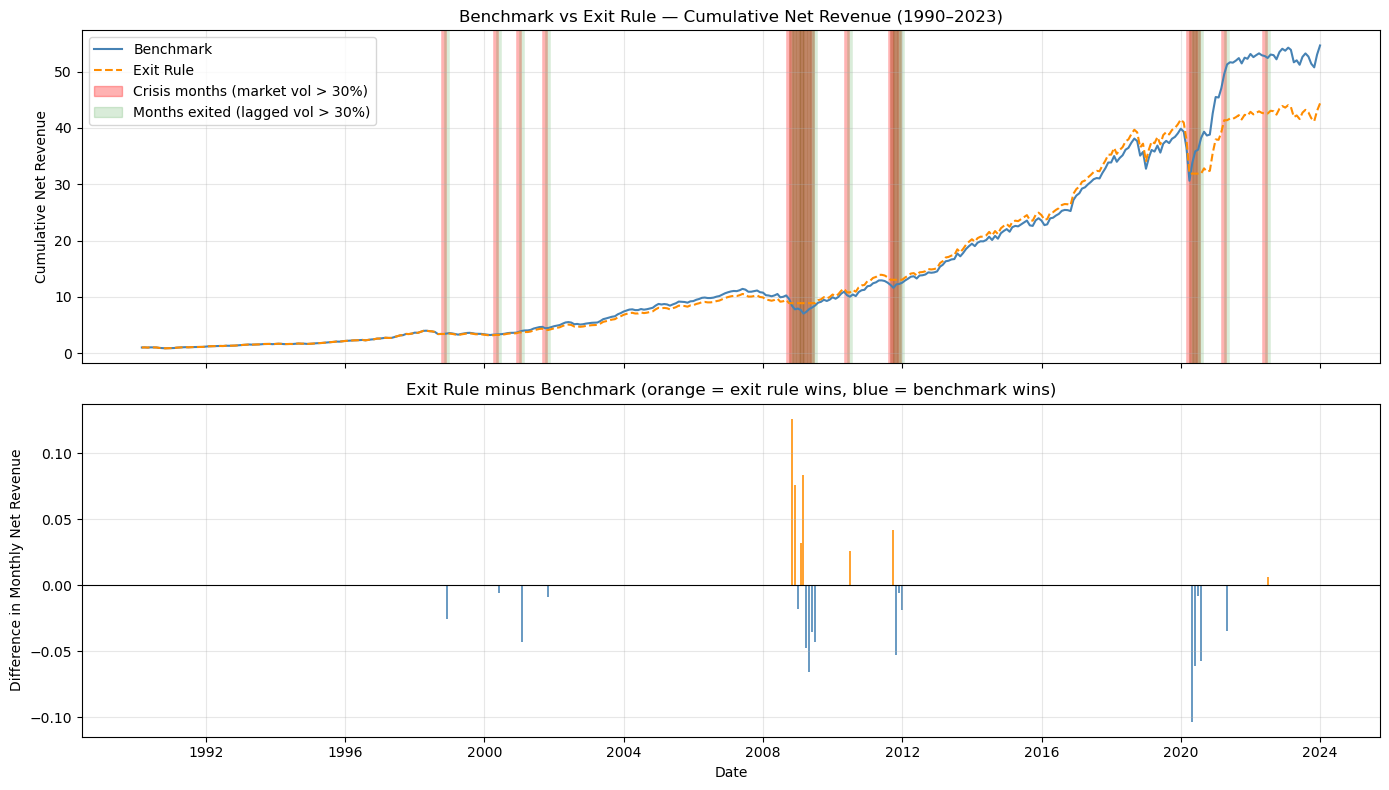

Plot saved to data/1B_exit_rule_performance.png ✅


In [7]:
# Cell 4 — Plot: Benchmark vs Exit Rule

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Plot 1: Cumulative net revenue ─────────────────────────
ax1.plot(benchmark_monthly['date'],
         benchmark_monthly['cumulative_net_revenue'],
         color='steelblue', linewidth=1.5, label='Benchmark')

ax1.plot(exit_rule_monthly['date'],
         exit_rule_monthly['cumulative_net_revenue'],
         color='darkorange', linewidth=1.5, label='Exit Rule', linestyle='--')

# Shade crisis months
for _, row in benchmark_monthly[benchmark_monthly['high_vol_regime']].iterrows():
    ax1.axvspan(row['date'], row['date'], alpha=0.3, color='red', linewidth=4)

# Shade exited months
for _, row in exit_rule_monthly[~exit_rule_monthly['invested']].iterrows():
    ax1.axvspan(row['date'], row['date'], alpha=0.15, color='green', linewidth=4)

ax1.set_ylabel('Cumulative Net Revenue')
ax1.set_title('Benchmark vs Exit Rule — Cumulative Net Revenue (1990–2023)')
ax1.grid(True, alpha=0.3)

# Legend
crisis_patch = mpatches.Patch(color='red', alpha=0.3, label='Crisis months (market vol > 30%)')
exit_patch   = mpatches.Patch(color='green', alpha=0.15, label='Months exited (lagged vol > 30%)')
bench_line   = plt.Line2D([0], [0], color='steelblue', linewidth=1.5, label='Benchmark')
exit_line    = plt.Line2D([0], [0], color='darkorange', linewidth=1.5,
                          linestyle='--', label='Exit Rule')
ax1.legend(handles=[bench_line, exit_line, crisis_patch, exit_patch])

# ── Plot 2: Difference (exit rule minus benchmark) ─────────
diff = exit_rule_monthly['avg_net_revenue'].values - benchmark_monthly['avg_net_revenue'].values
colors = ['darkorange' if d > 0 else 'steelblue' for d in diff]

ax2.bar(benchmark_monthly['date'], diff, width=20, color=colors, alpha=0.8)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylabel('Difference in Monthly Net Revenue')
ax2.set_xlabel('Date')
ax2.set_title('Exit Rule minus Benchmark (orange = exit rule wins, blue = benchmark wins)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_path / '1B_exit_rule_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to data/1B_exit_rule_performance.png ✅")

In [8]:
# ── Save Results for Model Comparison ──────────────────────
# Replace BOTH the dataframe name and the label depending on which model you are running:
#
#   Benchmark notebook:      summarise_portfolio(monthly_results,    label='benchmark')
#   Exit rule notebook:      summarise_portfolio(exit_rule_monthly,  label='benchmark_exitrule')
#   Model A notebook:        summarise_portfolio([change for Model A],    label='model_a')
#   Model B notebook:        summarise_portfolio([change for Model B],    label='model_b')

import importlib
import evaluation
importlib.reload(evaluation)
from evaluation import summarise_portfolio

summarise_portfolio(exit_rule_monthly,  label='benchmark_exitrule')

  BENCHMARK_EXITRULE — SUMMARY STATISTICS
Months:                    407
Avg monthly net revenue:   0.9726%
Avg annual net revenue:    11.6710%
Std monthly net revenue:   2.6880%
Sharpe ratio (annualized): 1.2534
Best month:  2020-11 (9.6861%)
Worst month: 2020-03 (-16.0244%)

--- CRISIS VS NORMAL ---
Normal months (383):  avg 1.1004%/month
Crisis months ( 24):  avg -1.0667%/month

--- OOS PERIOD (2010–2023) ---
Months:                    168
Avg annual net revenue:    10.9384%
Sharpe ratio (annualized): 1.0580

Saved to data/summary_benchmark_exitrule.json ✅
Saved to data/monthly_results_benchmark_exitrule.csv ✅


{'label': 'benchmark_exitrule',
 'full_period_annual_net_revenue': np.float64(0.11670957618891456),
 'full_period_sharpe': np.float64(1.2534093854214836),
 'full_period_worst_month': np.float64(-0.16024358319910198),
 'full_period_best_month': np.float64(0.0968613903336692),
 'crisis_avg_monthly': np.float64(-0.010667342390755638),
 'normal_avg_monthly': np.float64(0.011003697153486914),
 'oos_annual_net_revenue': np.float64(0.10938434402057519),
 'oos_sharpe': np.float64(1.0580455808546738)}